## Financial News Sentiment Analysis

### Libraries

In [1]:
# import libraries
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..'))) # Adding racine path of project to sys.path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
from src.preprocessing import * # Module created

warnings.filterwarnings('ignore')

### Import data and preprocessing

In [2]:
df = wrangle('../data/raw_analyst_ratings.csv') #Preprocessing function defined in src module
df.info()
df.head()

<class 'pandas.DataFrame'>
DatetimeIndex: 1407327 entries, 2020-06-05 14:30:54+00:00 to 2011-05-12 00:00:00+00:00
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   headline   1407327 non-null  str  
 1   url        1407327 non-null  str  
 2   publisher  1407327 non-null  str  
 3   stock      1407327 non-null  str  
dtypes: str(4)
memory usage: 53.7 MB


,headline,url,publisher,stock
date,,,,
2020-06-05 14:30:54+00:00,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,A
2020-06-03 14:45:20+00:00,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,A
2020-05-26 08:30:07+00:00,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,A
2020-05-22 16:45:06+00:00,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,A
2020-05-22 15:38:59+00:00,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,A


### Exploratory Data Analysis

#### Descriptive statistics

In [3]:
# Headline length
df["headline_length"] = df["headline"].apply(lambda i: len(i))
df.head()

,headline,url,publisher,stock,headline_length
date,,,,,
2020-06-05 14:30:54+00:00,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,A,39
2020-06-03 14:45:20+00:00,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,A,42
2020-05-26 08:30:07+00:00,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,A,29
2020-05-22 16:45:06+00:00,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,A,44
2020-05-22 15:38:59+00:00,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,A,87


In [4]:
df["headline_length"].describe()

count    1.407327e+06
mean     7.312054e+01
std      4.073532e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

In [5]:
# The database possess duplicates on subset columns "headline" and "publisher"
df.duplicated(subset=["headline","publisher"]).sum()

np.int64(555383)

In [6]:
# To access to the real number of articles per publisher, we need to drop duplicates on subset 
# columns "headline" and "publisher"
df_clean = df.drop_duplicates(subset=["headline","publisher"])

In [7]:
stats_publisher = df_clean["publisher"].value_counts()
stats_publisher = stats_publisher.reset_index()
stats_publisher.columns = ["publisher","count"]
top_publishers = stats_publisher.head(10)
top_publishers

,publisher,count
0,Paul Quintaro,210483
1,Benzinga Newsdesk,93272
2,Charles Gross,82143
3,Eddie Staley,53843
4,Hal Lindon,43392
5,Juan Lopez,27714
6,Vick Meyer,24658
7,Benzinga Staff,22644
8,Monica Gerson,21638
9,Benzinga_Newsdesk,18198


Text(0, 0.5, 'Publisher')

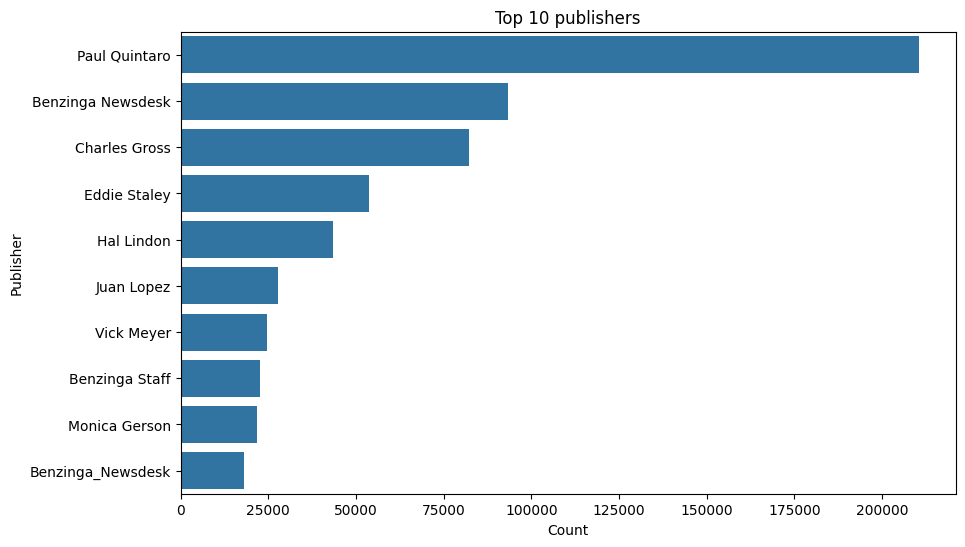

In [8]:
# Graph of the top 10 publishers
plt.figure(figsize=(10,6))
sns.barplot(x="count",y="publisher",data=top_publishers)
plt.title("Top 10 publishers")
plt.xlabel("Count")
plt.ylabel("Publisher")

#### Trend analysis of the publications

##### Day trend analysis

In [12]:
# We have data that are going from 2009-02-14 till 2020-06-11.
# Let's try to see the distribution of articles over day of the week
# We should use the clean database to avoid duplicates on subset columns "headline" and "publisher"

trend_per_day = df_clean.index.day_name().value_counts()
trend_per_day

date
Thursday     188552
Wednesday    186497
Tuesday      184092
Monday       160605
Friday       123641
Sunday         5610
Saturday       2947
Name: count, dtype: int64

Text(0.5, 1.0, 'Number of publications based per day')

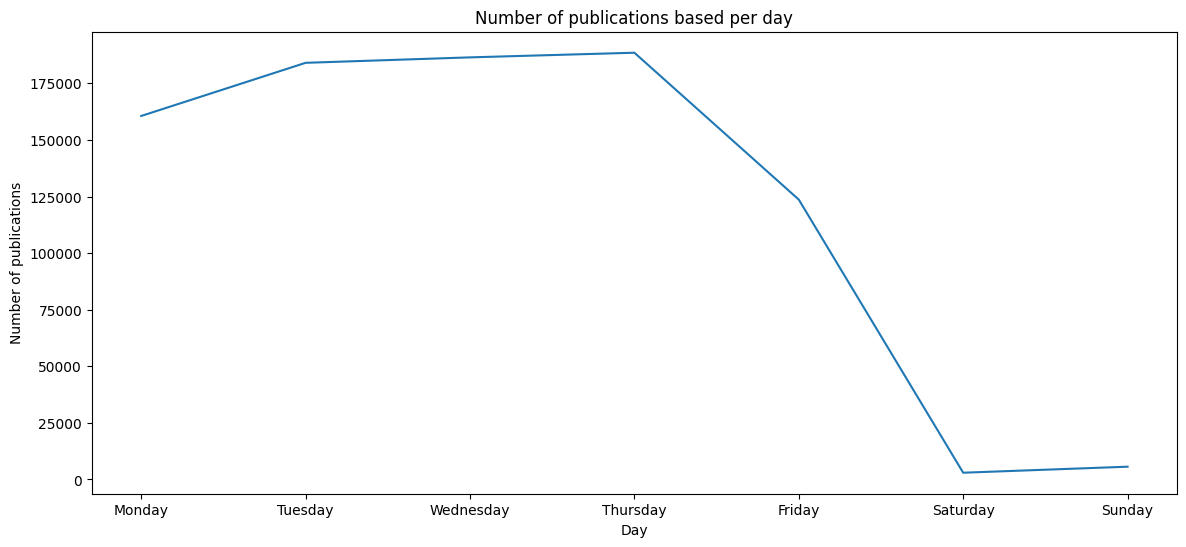

In [13]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
trend_per_day = trend_per_day.reindex(days_order)
plt.figure(figsize=(14,6))
trend_per_day.plot()
plt.xlabel('Day')
plt.ylabel('Number of publications')
plt.title('Number of publications based per day')

We notice that more of the articles are publish on work days (Monday to Friday) and week end days save less publications. The pic of publications is reach on Thursday